## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Load Dataset

In [2]:
df = pd.read_csv("spam.csv", encoding='latin-1')

## Show First 5 Rows

In [3]:
print("First 5 Rows:\n")
print(df.head())

First 5 Rows:

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


## Dataset Cleaning

In [4]:
# Keep only useful columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['Category', 'Message']

# Convert labels into numbers
# ham = 0 , spam = 1
df['Category'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})

## Check Missing Values

In [5]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Category    0
Message     0
dtype: int64


## Check Duplicate Values

In [6]:
print("\nDuplicate Values:", df.duplicated().sum())

# Remove Duplicates
df = df.drop_duplicates()


Duplicate Values: 403


## Data Visualization

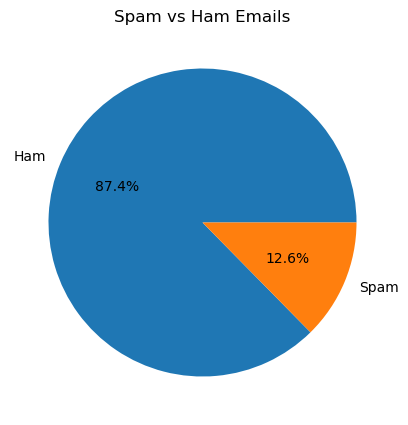

In [8]:
plt.figure(figsize=(5,5))

df['Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Ham', 'Spam']
)

plt.title("Spam vs Ham Emails")
plt.ylabel("")
plt.show()

## Split Dataset

In [9]:
X = df['Message']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Convert Text into Numerical Data

In [10]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    lowercase=True
)

X_train_features = vectorizer.fit_transform(X_train)
X_test_features = vectorizer.transform(X_test)

## Train Machine Learning Model

In [11]:
model = LogisticRegression()

model.fit(X_train_features, y_train)

LogisticRegression()

## Predictions

In [13]:
y_pred = model.predict(X_test_features)

## Model Evaluation

In [14]:
print("\nAccuracy Score:\n")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy Score:

0.9642166344294004

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       0.98      0.76      0.86       145

    accuracy                           0.96      1034
   macro avg       0.97      0.88      0.92      1034
weighted avg       0.96      0.96      0.96      1034



## Confusion Matrix

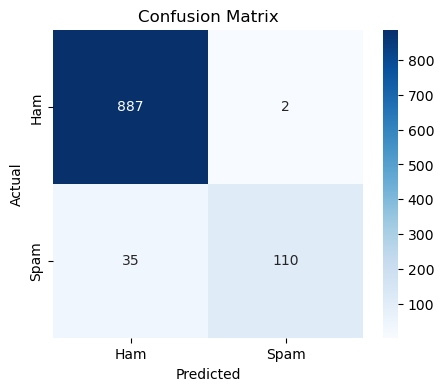

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Test with Custom Message

In [16]:
sample_message = ["Congratulations! You won a free iPhone. Click now!"]

sample_data = vectorizer.transform(sample_message)

prediction = model.predict(sample_data)

print("\nCustom Message Prediction:\n")

if prediction[0] == 1:
    print("Spam Mail")
else:
    print("Ham Mail")


Custom Message Prediction:

Ham Mail
